In [1]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("meetinglistdetails.csv")
df.head()

,Topic,Type,ID,Host name,Host email,Start time,End time,Participants,Duration (minutes),Total participant minutes,...,Max concurrent views,Creation time,Name (original name),Email,Join time,Leave time,Duration (minutes).1,Guest,Recording disclaimer response,In waiting room
0,Data Analysis using Python - Summer Online Int...,Meeting,932 5001 3841,santosh s,venkatasivasantosh.s@apssdc.in,05/30/2026 05:52:14 PM,05/30/2026 05:52:23 PM,1,1,1,...,-,05/05/2026 11:06:38 AM,santosh s (Host),venkatasivasantosh.s@apssdc.in,05/30/2026 05:52:14 PM,05/30/2026 05:52:23 PM,1,No,NaN,No
1,Machine Learning - Summer Online Internship -...,Meeting,970 1912 6650,santosh s,venkatasivasantosh.s@apssdc.in,05/30/2026 05:49:22 PM,05/30/2026 07:51:15 PM,2163,122,68311,...,-,05/05/2026 12:15:31 PM,Jaya Prakash Jagadam,jayaprakashjagadam7@gmail.com,05/30/2026 06:03:15 PM,05/30/2026 07:10:28 PM,68,Yes,No Response,No
2,Machine Learning - Summer Online Internship -...,Meeting,970 1912 6650,santosh s,venkatasivasantosh.s@apssdc.in,05/30/2026 05:49:22 PM,05/30/2026 07:51:15 PM,2163,122,68311,...,-,05/05/2026 12:15:31 PM,Shreshta K 25BFD58007 SVCE,shreshtasudhakar@gmail.com,05/30/2026 06:03:15 PM,05/30/2026 06:10:57 PM,8,Yes,No Response,No
3,Machine Learning - Summer Online Internship -...,Meeting,970 1912 6650,santosh s,venkatasivasantosh.s@apssdc.in,05/30/2026 05:49:22 PM,05/30/2026 07:51:15 PM,2163,122,68311,...,-,05/05/2026 12:15:31 PM,Ravilla Jeshitha,jeshitharavillajeshitha@gmail.com,05/30/2026 06:03:15 PM,05/30/2026 07:50:44 PM,108,Yes,OK,No
4,Machine Learning - Summer Online Internship -...,Meeting,970 1912 6650,santosh s,venkatasivasantosh.s@apssdc.in,05/30/2026 05:49:22 PM,05/30/2026 07:51:15 PM,2163,122,68311,...,-,05/05/2026 12:15:31 PM,ABHIRAM-24B91A0345-SRKR ( JONNALAGADDA ABHIRAM ),jonnalagadda.abhiram2007@gmail.com,05/30/2026 06:03:15 PM,05/30/2026 07:48:28 PM,106,Yes,OK,No


In [3]:
print(df.columns.tolist())

['Topic', 'Type', 'ID', 'Host name', 'Host email', 'Start time', 'End time', 'Participants', 'Duration (minutes)', 'Total participant minutes', 'Department', 'Group', 'Source', 'Unique viewers', 'Max concurrent views', 'Creation time', 'Name (original name)', 'Email', 'Join time', 'Leave time', 'Duration (minutes).1', 'Guest', 'Recording disclaimer response', 'In waiting room']


In [4]:
df = df[
    [
        'Name (original name)',
        'Email',
        'Duration (minutes).1'
    ]
]
print(df)

                                  Name (original name)  \
0                                     santosh s (Host)   
1                                 Jaya Prakash Jagadam   
2                           Shreshta K 25BFD58007 SVCE   
3                                     Ravilla Jeshitha   
4     ABHIRAM-24B91A0345-SRKR ( JONNALAGADDA ABHIRAM )   
...                                                ...   
4394      23A51A04G7-LINGALA Yuvraj ( Yuvaraj Krrish )   
4395      Avinash Kunche-24225A0203 ( Avinash Kunche )   
4396                                 Suravarapu Paandu   
4397                Devareddy Nanda Karthik-24B91A0234   
4398               24B91A0206 -AKULA NAGA VARA LAKSHMI   

                                   Email  Duration (minutes).1  
0         venkatasivasantosh.s@apssdc.in                     1  
1          jayaprakashjagadam7@gmail.com                    68  
2             shreshtasudhakar@gmail.com                     8  
3      jeshitharavillajeshitha@gmail.com   

In [5]:
df = df.dropna(subset=['Email'])

In [6]:
attendance = df.groupby(
    ['Name (original name)', 'Email']
)['Duration (minutes).1'].sum().reset_index()

In [7]:
join_count = df.groupby(
    ['Name (original name)', 'Email']
).size().reset_index(name='Join_Count')
attendance = attendance.merge(
    join_count,
    on=['Name (original name)', 'Email']
)

In [8]:
attendance.rename(
    columns={
        'Duration (minutes).1':'Total_Time'
    },
    inplace=True
)

In [9]:
SESSION_DURATION = 120

attendance['Attendance_Percentage'] = (
    attendance['Total_Time']
    /
    SESSION_DURATION
) * 100
attendance['Attendance'] = (
    attendance['Total_Time'] >= 90
).astype(int)
attendance['Status'] = attendance['Attendance'].map({
    1:'Present',
    0:'Absent'
})


,Name (original name),Email,Total_Time,Join_Count,Attendance_Percentage,Attendance,Status
0,( 24221A1209)bukkuru upendrakumar ( bukkuru up...,bukkuruupendrakumar@gmail.com,12,1,10.000000,0,Absent
1,(23001A0522)Indira Priyadarshini ( (23001A0522...,k.indira2006@gmail.com,27,1,22.500000,0,Absent
2,(23001A0527)N Sravani ( N Sravani ),sravanicse200@gmail.com,19,1,15.833333,0,Absent
3,(23221A0574)Ramya Manne,ramyamanne1326@gmail.com,22,1,18.333333,0,Absent
4,(234M1A0525) CHIRANJEEVI LALITH KUMAR-(Vemu IT),lalithkumar38879@gmail.com,46,1,38.333333,0,Absent
...,...,...,...,...,...,...,...
95,232U1A3346 KOPPAVARAPU JWALITHA NAGASRI,jwalithak256@gmail.com,113,2,94.166667,1,Present
96,23491A4498 Koteswari thummalapudi qis college,thummalapudikoteswari@gmail.com,98,1,81.666667,1,Present
97,234M1A0509 B.Bhavana(Vemu institute of technol...,bhavanabhupathi27@gmail.com,99,1,82.500000,1,Present
98,234M1A0518-BOLLINENI PUNITH NAIDU-VemuIT ( BOL...,bollinenipunithnaidu2005@gmail.com,86,1,71.666667,0,Absent


In [10]:
attendance['Certification_Status'] = attendance['Total_Time'].apply(
    lambda x: 'Certified' if x >= 90 else 'Not Certified'
)

In [48]:
attendance.head(100)

,Name (original name),Email,Total_Time,Join_Count,Attendance_Percentage,Attendance,Status,Certification_Status
0,( 24221A1209)bukkuru upendrakumar ( bukkuru up...,bukkuruupendrakumar@gmail.com,12,1,10.000000,0,Absent,Not Certified
1,(23001A0522)Indira Priyadarshini ( (23001A0522...,k.indira2006@gmail.com,27,1,22.500000,0,Absent,Not Certified
2,(23001A0527)N Sravani ( N Sravani ),sravanicse200@gmail.com,19,1,15.833333,0,Absent,Not Certified
3,(23221A0574)Ramya Manne,ramyamanne1326@gmail.com,22,1,18.333333,0,Absent,Not Certified
4,(234M1A0525) CHIRANJEEVI LALITH KUMAR-(Vemu IT),lalithkumar38879@gmail.com,46,1,38.333333,0,Absent,Not Certified
...,...,...,...,...,...,...,...,...
95,232U1A3346 KOPPAVARAPU JWALITHA NAGASRI,jwalithak256@gmail.com,113,2,94.166667,1,Present,Certified
96,23491A4498 Koteswari thummalapudi qis college,thummalapudikoteswari@gmail.com,98,1,81.666667,1,Present,Certified
97,234M1A0509 B.Bhavana(Vemu institute of technol...,bhavanabhupathi27@gmail.com,99,1,82.500000,1,Present,Certified
98,234M1A0518-BOLLINENI PUNITH NAIDU-VemuIT ( BOL...,bollinenipunithnaidu2005@gmail.com,86,1,71.666667,0,Absent,Not Certified


In [11]:
attendance.describe()

,Total_Time,Join_Count,Attendance_Percentage,Attendance
count,2387.00000,2387.000000,2387.000000,2387.000000
mean,48.42145,1.842899,40.351208,0.202765
std,36.56195,2.132069,30.468292,0.402143
min,1.00000,1.000000,0.833333,0.000000
25%,17.00000,1.000000,14.166667,0.000000
50%,41.00000,1.000000,34.166667,0.000000
75%,78.00000,2.000000,65.000000,0.000000
max,189.00000,55.000000,157.500000,1.000000


In [12]:
attendance['Status'].value_counts()

Status
Absent     1903
Present     484
Name: count, dtype: int64

In [13]:
X = attendance[
    [
        'Total_Time',
        'Join_Count'
    ]
]

In [14]:
y = attendance['Attendance']

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [16]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [17]:
y_pred = model.predict(X_test)

In [18]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy =", accuracy)

Accuracy = 1.0


In [19]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       370
           1       1.00      1.00      1.00       108

    accuracy                           1.00       478
   macro avg       1.00      1.00      1.00       478
weighted avg       1.00      1.00      1.00       478



[[370   0]
 [  0 108]]


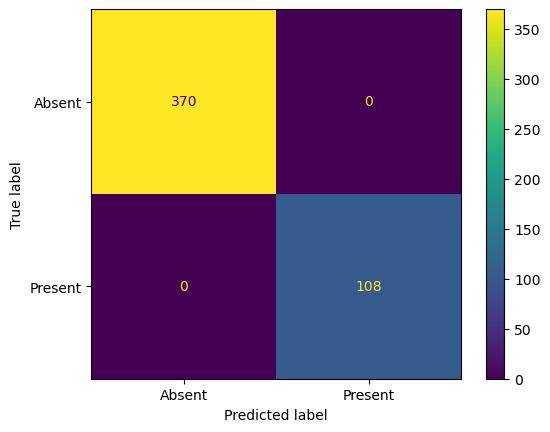

In [20]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Absent','Present']
)

disp.plot()

plt.show()

In [21]:
joblib.dump(
    model,
    "attendance_model.pkl"
)

print("Model Saved")

Model Saved


In [22]:
attendance.to_csv(
    "final_attendance.csv",
    index=False
)

print("Attendance File Saved")

Attendance File Saved


In [50]:
search = input("Enter Student Name or Email: ")

student = attendance[
    (attendance['Name (original name)'].astype(str).str.lower().str.strip()
     == search.lower().strip())
    |
    (attendance['Email'].astype(str).str.lower().str.strip()
     == search.lower().strip())
]

if student.empty:
    print("Student Not Found")
else:
    display(
        student[
            [
                'Name (original name)',
                'Email',
                'Total_Time',
                'Join_Count',
                'Attendance_Percentage',
                'Status',
                'Certification_Status'
            ]
        ]
    )

Enter Student Name or Email:  veerumerugu627@gmail.com


,Name (original name),Email,Total_Time,Join_Count,Attendance_Percentage,Status,Certification_Status
1347,Merugu Keerthi Bhavani 23BQ1A42A5(VVIT),veerumerugu627@gmail.com,113,1,94.166667,Present,Certified
